# Week 6 - Function 4 ((35DP, 4D))

# Setup
Let's load all the imports in the top to avoid repeating and simplify the readability of each solution.

In [19]:
import numpy as np
import torch
import gpytorch

from sklearn.preprocessing import MinMaxScaler, QuantileTransformer
from scipy.stats.qmc import LatinHypercube

from utils.plotting_utils import (
    plot_4D_initial_data,
    plot_output_outliers,
    plot_nd_mean_uncertainty_slice
)

In [20]:
# ── GPyTorch utilities (shared across migrated notebooks) ──────────────────────

class MaternARD_ExactGP(gpytorch.models.ExactGP):
    def __init__(self, X, y, likelihood, n_dims, ls_prior=None):
        super().__init__(X, y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        ls_prior = ls_prior or gpytorch.priors.GammaPrior(3.0, 6.0)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(
                nu=2.5, ard_num_dims=n_dims,
                lengthscale_prior=ls_prior
            ),
            outputscale_prior=gpytorch.priors.GammaPrior(2.0, 0.15)
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def fit_gpytorch_model(X_np, y_np, n_dims, noise=0.01, n_steps=300, lr=0.1, ls_prior=None):
    X_t = torch.tensor(X_np, dtype=torch.float64)
    y_t = torch.tensor(y_np, dtype=torch.float64)
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    likelihood.noise = noise
    model = MaternARD_ExactGP(X_t, y_t, likelihood, n_dims, ls_prior=ls_prior).double()
    likelihood = likelihood.double()
    model.train(); likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    losses = []
    for _ in range(n_steps):
        optimizer.zero_grad()
        loss = -mll(model(X_t), y_t)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
    model.eval(); likelihood.eval()
    return model, likelihood, losses


def gp_predict(model, likelihood, X_np):
    """Drop-in replacement for sklearn GP.predict(X, return_std=True)."""
    X_t = torch.tensor(X_np, dtype=torch.float64)
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood(model(X_t))
    return pred.mean.numpy(), pred.variance.sqrt().numpy()


def gp_converged_gpytorch(losses, min_loss_drop=0.1, max_final_loss=10.0):
    losses_arr = np.array(losses)
    loss_drop = losses_arr[0] - losses_arr[-1]
    converged = (not np.any(np.isnan(losses_arr))
                 and loss_drop >= min_loss_drop
                 and losses_arr[-1] < max_final_loss)
    return converged, {'loss_drop': loss_drop, 'final_loss': losses_arr[-1]}


# Plan
We now have ((35, 4)) — 35 data points, 4 dimensions, from `./data/week_6/function_4/`.

**Architecture**: Single GP (ARD Matern 2.5) with QuantileTransformer output and UCB acquisition.

**Key decisions:**
- **QuantileTransformer** (week 5 fix): outlier at y=−37.5 skews StandardScaler's mean/std; QT maps it to quantile≈0.03, preserving all points with correct ordinal structure
- UCB kappa=2.0 (exploitation-focused)
- 10K LHS candidates for acquisition

**Steps:** Load data → Preprocessing → GP model → GP visualization (2D slices) → Acquisition → Report

# 1. Load data

In [21]:
X_train_raw = np.load(r"./data/week_6/function_4/inputs.npy")
y_train_raw = np.load(r"./data/week_6/function_4/outputs.npy")
print(f"Shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"X range: [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}]")
print(f"y range: [{y_train_raw.min():.2e}, {y_train_raw.max():.2e}]")

Shape: X=(35, 4), y=(35,)
X range: [0.0063, 0.9995]
y range: [-3.75e+01, 4.01e-01]


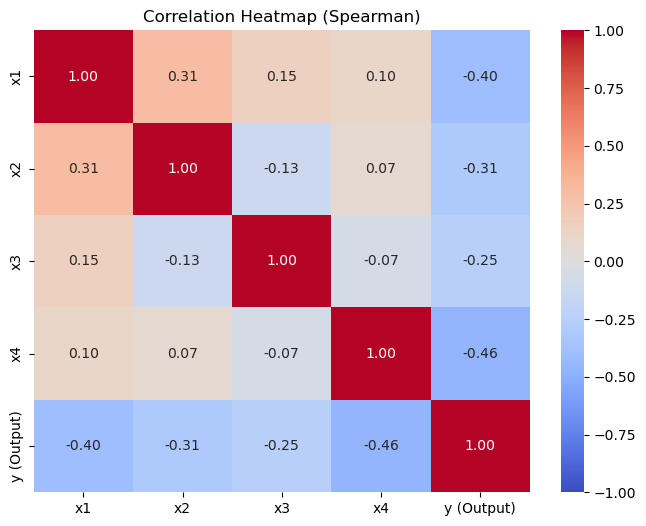

Generating Pairplot...


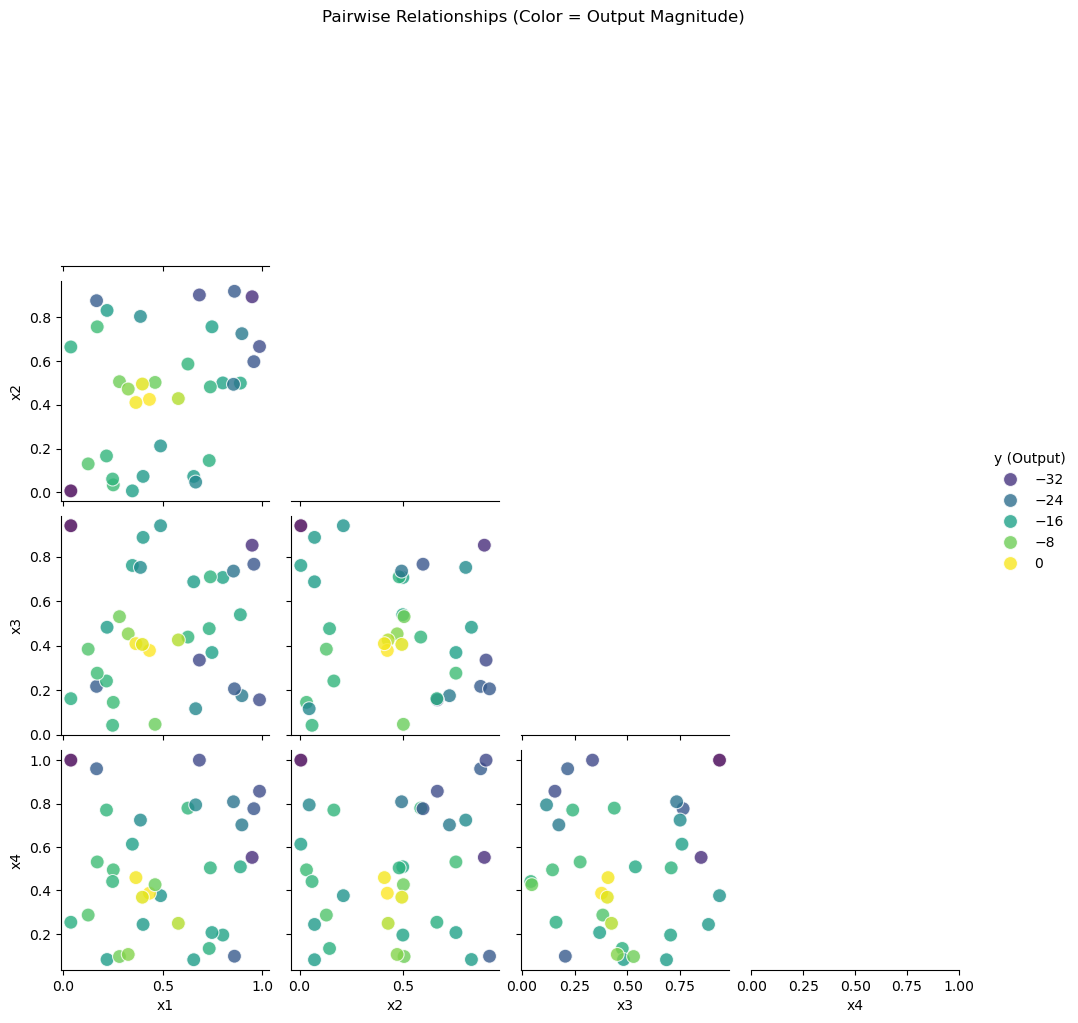

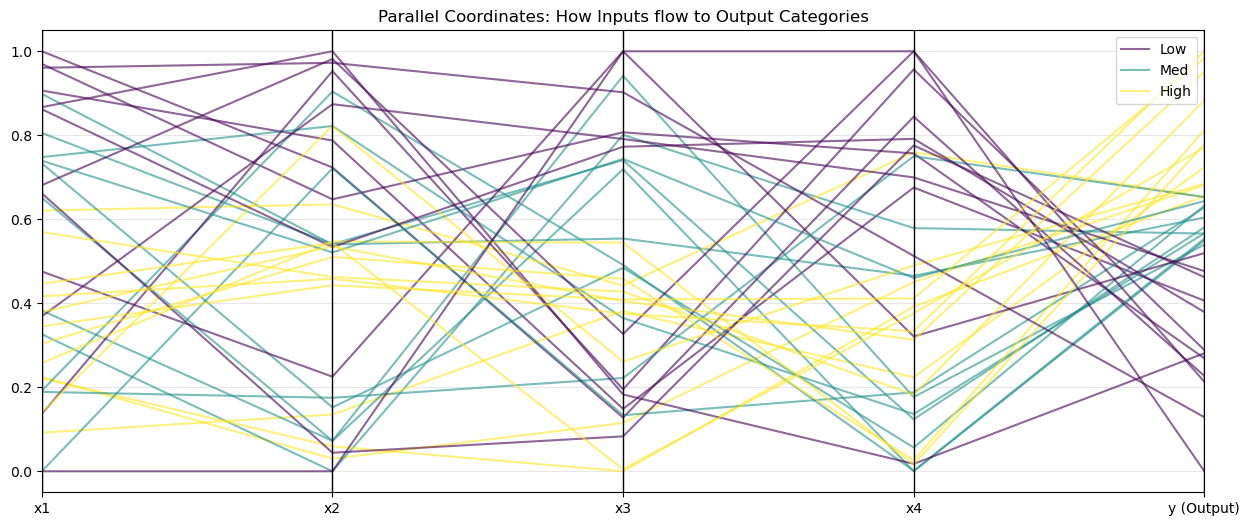

In [22]:
plot_4D_initial_data(X_train_raw, y_train_raw, "Step1: Data points", f"""
DATA SUMMARY
{'='*80}
Points: {len(X_train_raw)}
Input shape: {X_train_raw.shape}
Output shape: {y_train_raw.shape}


CURRENT BEST
{'='*80}
Current best: {np.max(y_train_raw)}
At input: {X_train_raw[np.argmax(y_train_raw)]}
""")

# 2. Preprocessing

1 minor outlier at y=−37.5 (below IQR fence). **Week 5 fix**: switching from StandardScaler → QuantileTransformer.
The outlier skews StandardScaler's mean/std, distorting GP covariance estimates across the whole space.
QuantileTransformer maps y=−37.5 to quantile≈0.03; all 34 points are preserved with correct ordinal structure.

In [23]:
scaler_X = MinMaxScaler()
# Switch from StandardScaler → QuantileTransformer for y.
# Reason: outlier y=−37.5 skews StandardScaler's mean/std, distorting GP covariance
# estimates across the entire space. QuantileTransformer maps y=−37.5 to quantile≈0.03
# while all other points remain well-distributed in (0, 1]. All 34 points are preserved;
# the GP still sees "that X region is bad" (gradient preserved), it just won't be
# dominated by the scale of the outlier.
scaler_y = QuantileTransformer(n_quantiles=len(y_train_raw), output_distribution='uniform')

X_train = scaler_X.fit_transform(X_train_raw)
y_train = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

print(f"Total points: {len(X_train)}")
print(f"Scaled y range: [{y_train.min():.4f}, {y_train.max():.4f}]  (QuantileTransformer → uniform [0,1])")
print(f"Outlier y=-37.5 maps to quantile: {y_train[np.argmin(y_train_raw)]:.4f}")
print(f"Best point: X={X_train_raw[np.argmax(y_train_raw)]}, y={y_train_raw.max():.2e}")

Total points: 35
Scaled y range: [0.0000, 1.0000]  (QuantileTransformer → uniform [0,1])
Outlier y=-37.5 maps to quantile: 0.0000
Best point: X=[0.43274  0.424865 0.378558 0.387505], y=4.01e-01


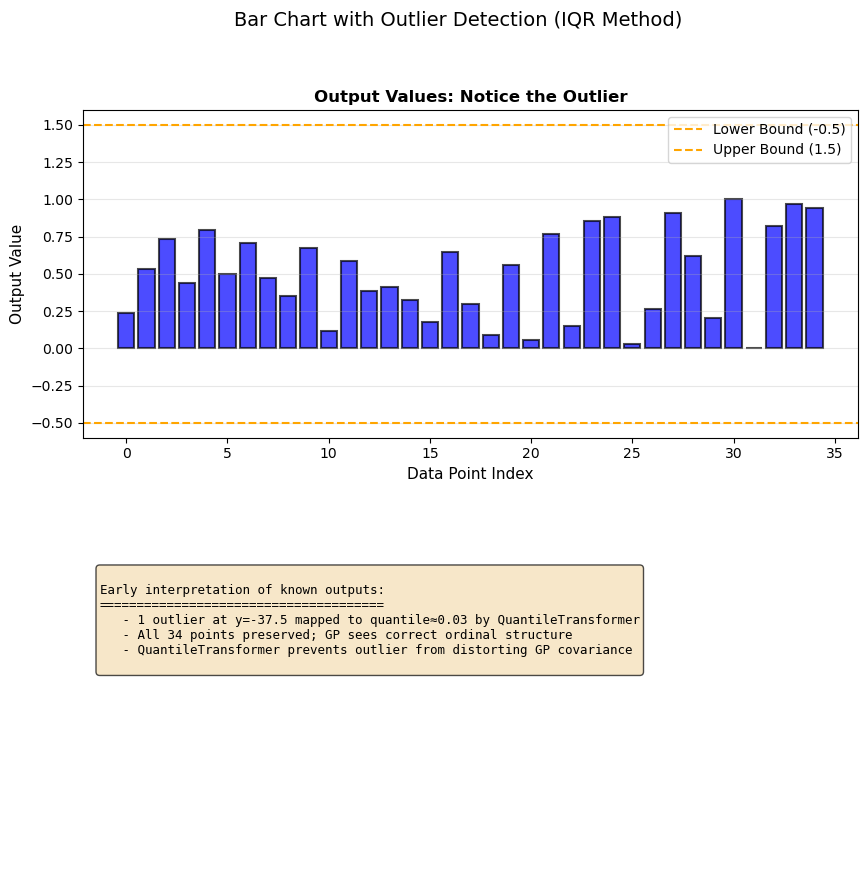

In [24]:
plot_output_outliers(X_train, y_train, "Bar Chart with Outlier Detection (IQR Method)", f"""
Early interpretation of known outputs:
{'='*38}
   - 1 outlier at y=-37.5 mapped to quantile≈0.03 by QuantileTransformer
   - All 34 points preserved; GP sees correct ordinal structure
   - QuantileTransformer prevents outlier from distorting GP covariance
""")

# 3. Build probabilistic Model

Single GP with ARD Matern 2.5 kernel. The ARD length scales will reveal which dimensions matter most.

In [25]:
# GPyTorch ARD Matern 2.5 GP on QuantileTransformer output (all 34 points).
# GammaPrior(2, 0.5) for lengthscale: mode=2.0, places mass near observed ls≈1.0–1.3.
# n_steps=400, lr=0.05: slower but more thorough search of MLL landscape vs L-BFGS-B.
# Previously kappa=2 did not help (exploitation trap) because sklearn's L-BFGS-B was
# finding local MLL minima → overconfident sigma near the current best.
ls_prior_fn4 = gpytorch.priors.GammaPrior(2.0, 0.5)  # mode=2.0
model, likelihood, losses = fit_gpytorch_model(
    X_train, y_train, n_dims=4, noise=0.01, n_steps=400, lr=0.05, ls_prior=ls_prior_fn4)

converged, conv_info = gp_converged_gpytorch(losses)
print(f"GP training: final_loss={conv_info['final_loss']:.4f}, loss_drop={conv_info['loss_drop']:.4f}, converged={converged}")

# Feature importance from ARD length scales
learned_scales = model.covar_module.base_kernel.lengthscale.detach().numpy().ravel()
outputscale = model.covar_module.outputscale.item()
print(f"Outputscale: {outputscale:.4f}  Noise: {likelihood.noise.item():.6f}")

importance = 1.0 / learned_scales
importance_norm = importance / importance.sum() * 100

print(f"\nFeature Importance (from ARD length scales):")
print(f"{'Dim':<6} {'Length Scale':<15} {'Importance %':<15} {'Role'}")
print("-" * 48)
sorted_dims = np.argsort(learned_scales)
for i in sorted_dims:
    role = 'IMPORTANT' if learned_scales[i] < 2.0 else ('moderate' if learned_scales[i] < 10.0 else 'noise')
    print(f"x{i+1:<5} {learned_scales[i]:<15.4f} {importance_norm[i]:<15.1f} {role}")

# Identify most/least important dims for interactive plotting
most_important = sorted_dims[:2]
least_important = sorted_dims[2:]
print(f"\nPlotting dims: x{most_important[0]+1}, x{most_important[1]+1} (most important)")
print(f"Slider dims: x{least_important[0]+1}, x{least_important[1]+1} (least important)")

GP training: final_loss=-0.3098, loss_drop=0.7011, converged=True
Outputscale: 0.5799  Noise: 0.001064

Feature Importance (from ARD length scales):
Dim    Length Scale    Importance %    Role
------------------------------------------------
x2     1.3717          27.2            IMPORTANT
x1     1.5211          24.5            IMPORTANT
x3     1.5365          24.3            IMPORTANT
x4     1.5553          24.0            IMPORTANT

Plotting dims: x2, x1 (most important)
Slider dims: x3, x4 (least important)


# 4. GP Visualization (2D slices)

Fix the 2 least important dimensions at selected values and view contour plots of the 2 most important dimensions. Two slices are shown: one at the spatial midpoint (0.5, 0.5) and one at the current best point's coordinates.

=== Slice at midpoint (x3=0.5, x4=0.5) ===


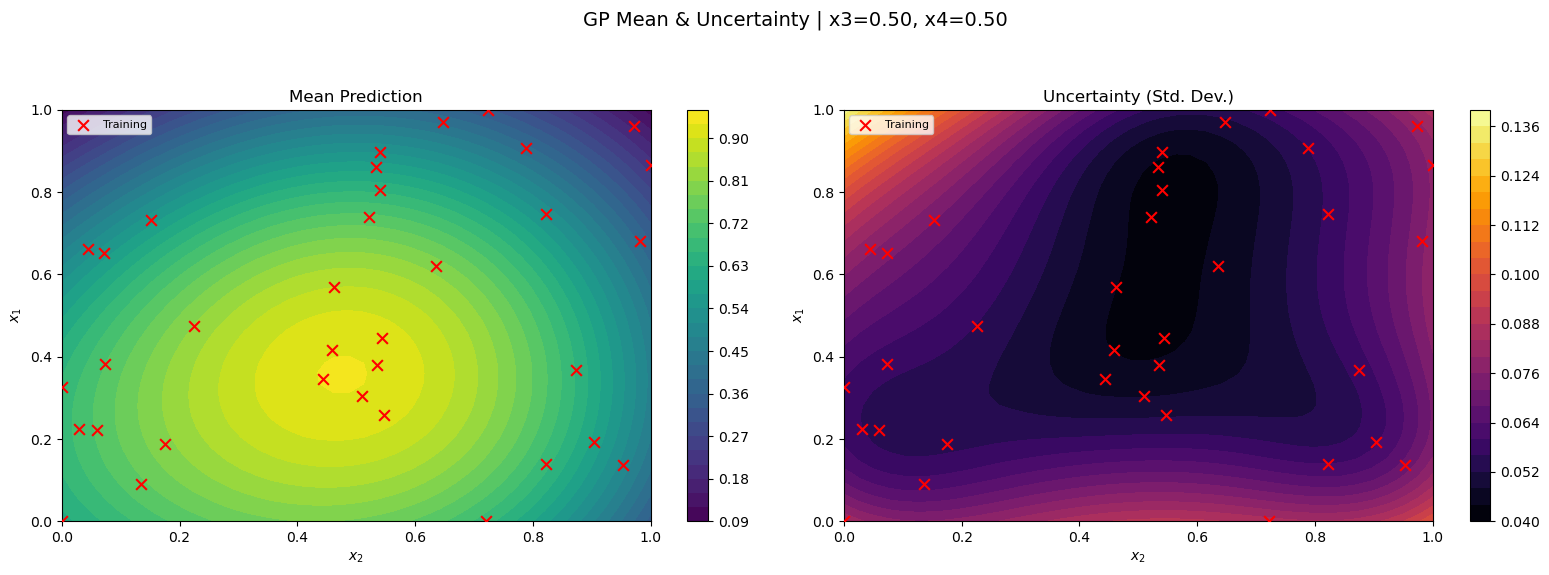


=== Slice at current best (x3=0.37, x4=0.33) ===


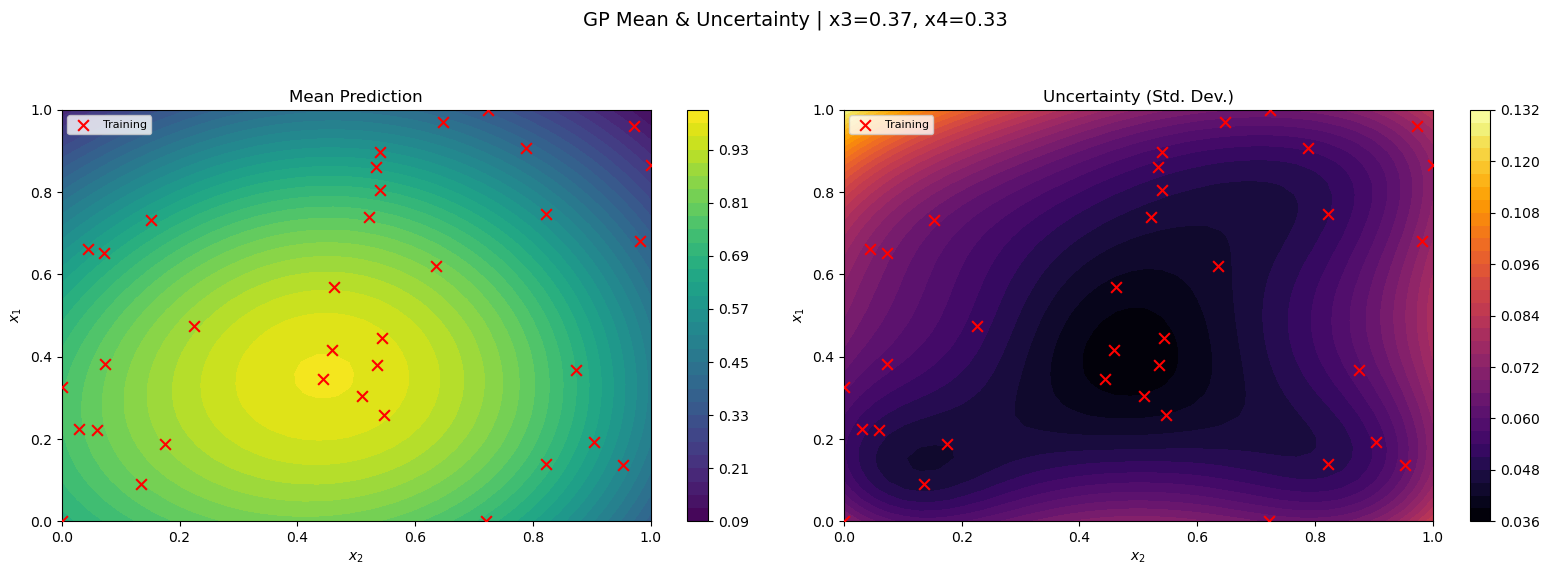

In [26]:
n_grid_2d = 40
x_plot_1 = np.linspace(0, 1, n_grid_2d)
x_plot_2 = np.linspace(0, 1, n_grid_2d)
X1_plot, X2_plot = np.meshgrid(x_plot_1, x_plot_2)

dim_a, dim_b = most_important[0], most_important[1]
dim_c, dim_d = least_important[0], least_important[1]

def plot_gp_slice(fix_c=0.5, fix_d=0.5):
    # Build full 4D grid with 2 dims varying and 2 fixed
    grid_4d = np.zeros((n_grid_2d * n_grid_2d, 4))
    grid_4d[:, dim_a] = X1_plot.ravel()
    grid_4d[:, dim_b] = X2_plot.ravel()
    grid_4d[:, dim_c] = fix_c
    grid_4d[:, dim_d] = fix_d

    mu, sigma = gp_predict(model, likelihood, grid_4d)

    fixed_info = f'x{dim_c+1}={fix_c:.2f}, x{dim_d+1}={fix_d:.2f}'
    plot_nd_mean_uncertainty_slice(
        X_train, X1_plot, X2_plot,
        mu.reshape(n_grid_2d, n_grid_2d),
        sigma.reshape(n_grid_2d, n_grid_2d),
        dim1_idx=dim_a, dim2_idx=dim_b,
        title_prefix='GP Mean & Uncertainty',
        fixed_info=fixed_info
    )

# Slice 1: midpoint
print("=== Slice at midpoint (x{c}=0.5, x{d}=0.5) ===".format(c=dim_c+1, d=dim_d+1))
plot_gp_slice(fix_c=0.5, fix_d=0.5)

# Slice 2: best known point's fixed-dim values
best_idx = np.argmax(y_train_raw)
best_fix_c = float(X_train[best_idx, dim_c])
best_fix_d = float(X_train[best_idx, dim_d])
print(f"\n=== Slice at current best (x{dim_c+1}={best_fix_c:.2f}, x{dim_d+1}={best_fix_d:.2f}) ===")
plot_gp_slice(fix_c=best_fix_c, fix_d=best_fix_d)

# 5. Acquisition Function (UCB on LHS candidates)

Replace the coarse meshgrid with Latin Hypercube Sampling to get 10,000 well-distributed candidates across all 4 dimensions. This avoids the boundary-bias issue of coarse grids in 4D.

In [27]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    return mu + kappa * sigma

# Generate LHS candidates
sampler = LatinHypercube(d=4, seed=42)
X_candidates = sampler.random(n=10_000)  # 10K points in [0,1]^4

# GP predictions on candidates
mu_cand, sigma_cand = gp_predict(model, likelihood, X_candidates)

# kappa=2.0 (exploitation-focused).
# Budget-aware formula gives 3.85 at week 6 (WEEK=6, kappa=5-(5/13)*3=3.846).
# Keep kappa=2.0 as escape hatch: GPyTorch provides better calibrated sigma so
# boundary-chasing should be less of an issue, but we start conservative and
# can raise if the recommendation is still near a known good region.
WEEK = 6
kappa = 2.0
print(f"kappa = {kappa:.4f} (week {WEEK}/13, exploitation-focused; budget-aware gives {5.0 - ((WEEK-1)/13)*3.0:.2f})")

ucb_values = upper_confidence_bound(mu_cand, sigma_cand, kappa=kappa)

best_idx = np.argmax(ucb_values)
x_next_norm = X_candidates[best_idx]
x_next_orig = scaler_X.inverse_transform([x_next_norm])[0]

print(f"{'='*71}")
print(f"RECOMMENDED NEXT POINT (UCB, kappa={kappa:.2f}, 10K LHS candidates)")
print(f"{'='*71}")
print(f"  Input (original space): {np.array_str(x_next_orig, precision=6)}")

y_pred, y_std = gp_predict(model, likelihood, np.array([x_next_norm]))
print(f"  GP prediction (QT space): {y_pred[0]:.4f} +/- {y_std[0]:.4f}")
print(f"  UCB value: {ucb_values[best_idx]:.4f}")

print(f"\nSanity check - is this a corner?")
for i in range(4):
    at_boundary = x_next_norm[i] < 0.02 or x_next_norm[i] > 0.98
    print(f"  x{i+1} = {x_next_norm[i]:.4f} {'<-- BOUNDARY!' if at_boundary else ''}")

print(f"\nCurrent best: {X_train_raw[np.argmax(y_train_raw)]} (y = {y_train_raw.max():.6f})")

X_next = x_next_orig
print(f"\nX_next = {X_next}")

# Machine-readable tag for get_submission.py
print(f"\nSUBMISSION: {'-'.join(f'{x:.6f}' for x in x_next_orig)}")

kappa = 2.0000 (week 6/13, exploitation-focused; budget-aware gives 3.85)
RECOMMENDED NEXT POINT (UCB, kappa=2.00, 10K LHS candidates)
  Input (original space): [0.37931  0.39552  0.312274 0.417981]
  GP prediction (QT space): 0.9904 +/- 0.0402
  UCB value: 1.0709

Sanity check - is this a corner?
  x1 = 0.3603 
  x2 = 0.4262 
  x3 = 0.3011 
  x4 = 0.3665 

Current best: [0.43274  0.424865 0.378558 0.387505] (y = 0.401305)

X_next = [0.3793101  0.39551972 0.31227352 0.41798099]

SUBMISSION: 0.379310-0.395520-0.312274-0.417981
